# Online Boutique AIOps — 数据集读取与自动化训练/评测 Pipeline

本 notebook 演示如何使用 `online_boutique_rca_full_v1` 数据集：

1. **读取数据集**（train / valid / test 三个划分 + 隐藏的 test 答案）
2. **实现你自己的算法**（只需实现 `fit` 和 `predict` 两个方法）
3. **交给 Pipeline 自动完成**：标准化 → 训练 → 推理 → 评测 → 绘图
4. **查看结果**：所有产物按时间戳存入 `output/<timestamp>_<run_name>/`，不会互相覆盖

---

### 防泄露设计（重要）

- 数据集按**采集时间顺序**划分：train 全部早于 valid，valid 早于 test，无未来信息泄露。
- 标准化统计量（mean/std）**只在 train 上拟合**，pipeline 自动用同一组统计量变换 valid/test。
- **test 的标签不在 `processed/`**，只在 `answers/`，你的算法看不到 test 答案。

## 0. 环境准备

从项目根目录运行本 notebook（`benchmark` 包需在 import 路径上）。

In [1]:
import sys
from pathlib import Path

# 确保能 import 到项目的 benchmark 包（notebook 在 notebooks/ 下，项目根在上一级）
ROOT = Path.cwd()
if (ROOT / "benchmark").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "benchmark").exists():
    PROJECT_ROOT = ROOT.parent
else:
    raise RuntimeError("找不到 benchmark 包，请从项目根目录或 notebooks/ 运行")
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from benchmark.pipeline import Pipeline, DatasetBundle, PipelineContext

DATASET = PROJECT_ROOT / "data" / "datasets" / "online_boutique_rca_full_v1"
print("项目根:", PROJECT_ROOT)
print("数据集:", DATASET)

项目根: s:\workspace\AIOPs\TM2026
数据集: s:\workspace\AIOPs\TM2026\data\datasets\online_boutique_rca_full_v1


## 1. 读取数据集

`DatasetBundle.load()` 一次性加载所有划分、答案文件、标准化统计量与元信息。

In [2]:
bundle = DatasetBundle.load(DATASET)

print("数据集:", bundle.meta["dataset_name"])
print("划分策略:", bundle.meta["split_policy"])
print("采样间隔:", bundle.sampling_interval_seconds, "秒")
print("特征数:", len(bundle.feature_cols))
print()
print(f"train: {len(bundle.train_x):5d} 行 | 异常点 {bundle.meta['train_anomaly_points']:4d} | runs={bundle.meta['train_runs']}")
print(f"valid: {len(bundle.valid_x):5d} 行 | 异常点 {bundle.meta['valid_anomaly_points']:4d} | runs={bundle.meta['valid_runs']}")
print(f"test : {len(bundle.test_x):5d} 行 | 异常点 {bundle.meta['test_anomaly_points']:4d} | runs={bundle.meta['test_runs']}")
print(f"test incidents: {len(bundle.test_incidents)} 个故障事件（含 effect_start/end）")

数据集: online_boutique_rca_full_v1
划分策略: last3_valid_last2_test
采样间隔: 5.0 秒
特征数: 63

train:  8570 行 | 异常点 1251 | runs=['online_boutique_rca_1', 'online_boutique_rca_2', 'online_boutique_rca_3', 'online_boutique_rca_4']
valid:  1496 行 | 异常点  235 | runs=['online_boutique_rca_5']
test :  2867 行 | 异常点  473 | runs=['online_boutique_rca_6', 'online_boutique_rca_7']
test incidents: 40 个故障事件（含 effect_start/end）


In [3]:
# 检查时序顺序：train 结束 < valid 开始 < test 开始
print("train:", bundle.train_x.timestamp.min(), "->", bundle.train_x.timestamp.max())
print("valid:", bundle.valid_x.timestamp.min(), "->", bundle.valid_x.timestamp.max())
print("test :", bundle.test_x.timestamp.min(),  "->", bundle.test_x.timestamp.max())
assert bundle.train_x.timestamp.max() < bundle.valid_x.timestamp.min() < bundle.test_x.timestamp.min()
print("\n时序顺序正确，无未来信息泄露。")

train: 2026-05-29T05:24:14Z -> 2026-05-30T07:38:42Z
valid: 2026-05-30T10:29:26Z -> 2026-05-30T12:34:01Z
test : 2026-05-30T12:55:57Z -> 2026-05-30T16:58:53Z

时序顺序正确，无未来信息泄露。


In [4]:
# 看一眼特征与标签
display(bundle.train_x.head(3))
display(bundle.train_y.head(3))
print("标签列:", list(bundle.train_y.columns))
print("phase 取值:", bundle.train_y.phase.unique().tolist())
print("\ntest incidents 字段:", list(bundle.test_incidents.columns))
display(bundle.test_incidents[["incident_id", "fault_type", "target_service", "effect_start", "effect_end"]].head(4))

,timestamp,frontend_qps,frontend_latency_p95,frontend_error_rate,frontend_cpu_usage,frontend_memory_usage,frontend_restart_count,cartservice_qps,cartservice_latency_p95,cartservice_error_rate,...,shippingservice_restart_count,adservice_qps,adservice_latency_p95,adservice_error_rate,adservice_cpu_usage,adservice_memory_usage,adservice_restart_count,redis-cart_cpu_usage,redis-cart_memory_usage,redis-cart_restart_count
0,2026-05-29T05:24:14Z,2.8,1062.5,0.0,0.022949,57.867188,2.0,5.333333,4.808811,0.0,...,2.0,2.733236,4.800000,0.0,0.008999,133.554688,2.0,0.0047,47.785156,2.0
1,2026-05-29T05:24:19Z,2.8,1062.5,0.0,0.021863,58.164062,2.0,5.733836,4.845714,0.0,...,2.0,2.400480,4.830159,0.0,0.007870,133.929688,2.0,0.0047,47.785156,2.0
2,2026-05-29T05:24:24Z,2.8,1062.5,0.0,0.021149,58.164062,2.0,5.733836,4.845714,0.0,...,2.0,2.400480,4.830159,0.0,0.006713,133.929688,2.0,0.0047,47.785156,2.0


,timestamp,is_anomaly,incident_id,phase
0,2026-05-29T05:24:14Z,0,NaN,normal
1,2026-05-29T05:24:19Z,0,NaN,normal
2,2026-05-29T05:24:24Z,0,NaN,normal


标签列: ['timestamp', 'is_anomaly', 'incident_id', 'phase']
phase 取值: ['normal', 'fault_effect']

test incidents 字段: ['incident_id', 'injection_start', 'injection_end', 'effect_start', 'effect_end', 'recovery_end', 'fault_type', 'target_service', 'root_cause_service', 'severity', 'duration_sec', 'valid_incident', 'root_cause_dims', 'secondary_dims', 'run_id']


,incident_id,fault_type,target_service,effect_start,effect_end
0,online_boutique_rca_6/INC-001,cpu_stress,recommendationservice,2026-05-30T13:01:02Z,2026-05-30T13:02:00Z
1,online_boutique_rca_6/INC-002,pod_kill,cartservice,2026-05-30T13:07:21Z,2026-05-30T13:08:19Z
2,online_boutique_rca_6/INC-003,cpu_stress,recommendationservice,2026-05-30T13:13:54Z,2026-05-30T13:14:52Z
3,online_boutique_rca_6/INC-004,pod_kill,cartservice,2026-05-30T13:19:22Z,2026-05-30T13:20:21Z


## 2. 可视化数据（可选）

看看故障期间的指标变化。cpu_stress 会抬高 recommendationservice 的 CPU 与延迟，pod_kill 会引发 cartservice 的 restart/error。

C:\Users\13744\AppData\Local\Temp\ipykernel_10920\2670580849.py:17: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\13744\AppData\Local\Temp\ipykernel_10920\2670580849.py:17: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\13744\AppData\Local\Temp\ipykernel_10920\2670580849.py:17: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\13744\AppData\Local\Temp\ipykernel_10920\2670580849.py:17: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\13744\AppData\Local\Temp\ipykernel_10920\2670580849.py:17: UserWarning: Glyph 27225 (\N{CJK UNIFIED IDEOGRAPH-6A59}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\13744\AppData\Local\Temp\i

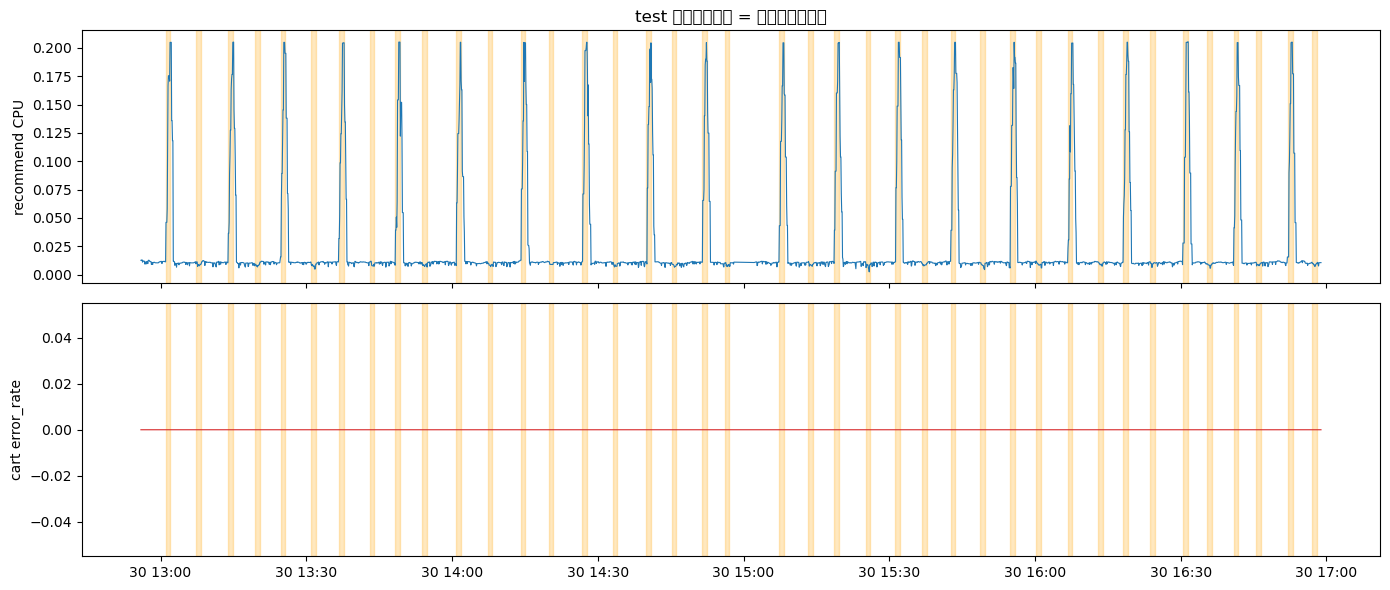

In [5]:
ty = bundle.test_x.copy()
ty["is_anomaly"] = bundle.test_truth["y_true"].values
ts = pd.to_datetime(ty.timestamp)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ts, ty["recommendationservice_cpu_usage"], lw=0.8)
axes[0].set_ylabel("recommend CPU")
axes[0].set_title("test 集指标（橙色 = 真实异常区间）")
axes[1].plot(ts, ty["cartservice_error_rate"], lw=0.8, color="#d62728")
axes[1].set_ylabel("cart error_rate")
for ax in axes:
    prev = 0; start = None
    for i, v in enumerate(ty.is_anomaly.values):
        if v and not prev: start = ts.iloc[i]
        elif not v and prev: ax.axvspan(start, ts.iloc[i], color="orange", alpha=0.25)
        prev = v
plt.tight_layout(); plt.show()

## 3. 实现你的算法 （⭐ 用户在这里写代码）

实现一个检测器类，只需两个方法：

```python
def fit(self, train_x, train_y, valid_x, valid_y, ctx):
    # 在这里训练。train_x/valid_x 已由 pipeline 用 train-only 统计量标准化。
    # 无监督方法可忽略 *_y。

def predict(self, test_x, ctx) -> np.ndarray:
    # 返回一维异常分数，长度 == len(test_x)，值越大越异常。
```

`ctx` 提供：`ctx.feature_cols`、`ctx.norm_stats`、`ctx.meta`、`ctx.output_dir`、`ctx.scale(df)`。

下面给出一个**示例实现**（高斯概率密度基线），你可以直接替换成自己的模型（Isolation Forest、AutoEncoder、LSTM 等）。

In [6]:
# =========================
# USAD Detector V3: robust top-k calibrated score + fixed FPR threshold
# 重点修复：z-score 数据 + 无界线性 decoder 会导致对抗损失爆炸。
# 本版在 detector 内部用 train-only 分位数把输入压到 [0,1]，decoder 末端使用 Sigmoid，
# 更接近 USAD 论文实现，并加入 pretrain_epochs 稳定训练。
# =========================

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


class SingleUSADDetector:
    """
    USAD: UnSupervised Anomaly Detection on Multivariate Time Series.

    Pipeline 接口：
    - fit(train_x, train_y, valid_x, valid_y, ctx)
    - predict(test_x, ctx) -> 长度等于 len(test_x) 的 anomaly_score

    V3 修复点：
    1. pipeline 已经做 z-score，但原论文 decoder 使用 Sigmoid，适合 [0,1] 输入。
       因此这里在 detector 内部再用 train-only 分位数缩放到 [0,1]。
    2. 先预训练 AE1/AE2 若干轮，再进入 USAD 对抗训练，避免 early-stage 发散。
    3. AE2 的“负重构误差”项用 adv_weight 控制，防止无界放大。
    """

    def __init__(
        self,
        window_size=12,
        latent_dim=64,
        pretrain_epochs=20,
        epochs=60,
        batch_size=256,
        lr=1e-3,
        alpha=0.5,
        beta=0.5,
        topk_features=5,
        adv_weight=0.1,
        seed=42,
        grad_clip=1.0,
        device=None,
    ):
        assert abs(alpha + beta - 1.0) < 1e-8, "alpha + beta 必须等于 1"
        self.window_size = int(window_size)
        self.latent_dim = int(latent_dim)
        self.pretrain_epochs = int(pretrain_epochs)
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.lr = float(lr)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.topk_features = int(topk_features)
        self.adv_weight = float(adv_weight)
        self.seed = int(seed)
        self.grad_clip = grad_clip
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

        self.cols = None
        self.model = None
        self.input_dim = None

        # train-only 内部 min-max/quantile 缩放参数
        self.q_low = None
        self.q_high = None

        # 用训练集正常窗口的逐特征误差做鲁棒校准，降低全局均值分数导致的误报
        self.err_center = None
        self.err_scale = None
        self.score_eps = 1e-6

    # ---------- 基础工具 ----------

    def _set_seed(self):
        random.seed(self.seed)
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(self.seed)

    def _df_to_x_raw(self, df, ctx):
        self.cols = [c for c in ctx.feature_cols if c in df.columns] if self.cols is None else self.cols
        x = df[self.cols].to_numpy(dtype=np.float32)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        return x

    def _fit_inner_scaler(self, x, y=None):
        """
        只用训练集统计量；优先用正常点拟合，避免异常污染压缩尺度。
        使用 1%/99% 分位数而不是 min/max，减少极端点影响。
        """
        x_fit = x
        if y is not None:
            y = np.asarray(y).astype(int)
            if len(y) == len(x) and np.any(y == 0):
                x_fit = x[y == 0]

        self.q_low = np.quantile(x_fit, 0.01, axis=0).astype(np.float32)
        self.q_high = np.quantile(x_fit, 0.99, axis=0).astype(np.float32)

        span = self.q_high - self.q_low
        span[span < 1e-6] = 1.0
        self.q_high = self.q_low + span

    def _transform_inner(self, x):
        x = (x - self.q_low) / (self.q_high - self.q_low)
        x = np.clip(x, 0.0, 1.0)
        return x.astype(np.float32)

    def _make_windows(self, x):
        """
        x: [T, D]
        return: [T-K+1, K*D]
        """
        k = self.window_size
        if len(x) < k:
            raise ValueError(f"数据长度 {len(x)} 小于 window_size={k}")

        windows = np.lib.stride_tricks.sliding_window_view(x, window_shape=k, axis=0)
        if windows.shape[1] == x.shape[1] and windows.shape[2] == k:
            windows = np.transpose(windows, (0, 2, 1))
        return windows.reshape(windows.shape[0], -1).astype(np.float32)

    def _make_window_labels(self, y):
        k = self.window_size
        y = np.asarray(y).astype(int)
        return np.array(
            [int(np.max(y[i:i + k]) > 0) for i in range(len(y) - k + 1)],
            dtype=np.int64,
        )

    def _window_scores_to_point_scores(self, window_scores, total_len):
        k = self.window_size
        point_scores = np.zeros(total_len, dtype=np.float32)
        point_scores[k - 1:] = window_scores
        point_scores[:k - 1] = window_scores[0]
        return point_scores

    # ---------- 模型结构 ----------

    class _Encoder(nn.Module):
        def __init__(self, input_dim, latent_dim):
            super().__init__()
            h1 = max(input_dim // 2, latent_dim * 2)
            h2 = max(input_dim // 4, latent_dim)
            self.net = nn.Sequential(
                nn.Linear(input_dim, h1),
                nn.ReLU(),
                nn.Linear(h1, h2),
                nn.ReLU(),
                nn.Linear(h2, latent_dim),
                nn.ReLU(),
            )

        def forward(self, x):
            return self.net(x)

    class _Decoder(nn.Module):
        def __init__(self, input_dim, latent_dim):
            super().__init__()
            h2 = max(input_dim // 4, latent_dim)
            h1 = max(input_dim // 2, latent_dim * 2)
            self.net = nn.Sequential(
                nn.Linear(latent_dim, h2),
                nn.ReLU(),
                nn.Linear(h2, h1),
                nn.ReLU(),
                nn.Linear(h1, input_dim),
                nn.Sigmoid(),  # 输入已缩放到 [0,1]，用 Sigmoid 限制输出，防止对抗项无界发散
            )

        def forward(self, z):
            return self.net(z)

    class _USAD(nn.Module):
        def __init__(self, input_dim, latent_dim):
            super().__init__()
            self.encoder = SingleUSADDetector._Encoder(input_dim, latent_dim)
            self.decoder1 = SingleUSADDetector._Decoder(input_dim, latent_dim)
            self.decoder2 = SingleUSADDetector._Decoder(input_dim, latent_dim)

        def ae1(self, x):
            return self.decoder1(self.encoder(x))

        def ae2(self, x):
            return self.decoder2(self.encoder(x))

    # ---------- 训练 ----------

    def fit(self, train_x, train_y, valid_x, valid_y, ctx):
        self._set_seed()

        X_raw = self._df_to_x_raw(train_x, ctx)
        y_train = None
        if train_y is not None and "is_anomaly" in train_y.columns:
            y_train = train_y["is_anomaly"].to_numpy(dtype=int)

        self._fit_inner_scaler(X_raw, y=y_train)
        X_train = self._transform_inner(X_raw)

        W_train = self._make_windows(X_train)

        # 训练只保留全正常窗口
        if y_train is not None:
            wy = self._make_window_labels(y_train)
            W_train = W_train[wy == 0]

        if len(W_train) == 0:
            raise ValueError("没有可训练的正常窗口。请减小 window_size 或检查 train_y。")

        self.input_dim = W_train.shape[1]
        self.model = self._USAD(self.input_dim, self.latent_dim).to(self.device)

        ds = TensorDataset(torch.from_numpy(W_train))
        loader = DataLoader(ds, batch_size=self.batch_size, shuffle=True, drop_last=False)

        mse = nn.MSELoss()

        # 预训练阶段：联合训练 encoder + decoder1 + decoder2，让两个 AE 先学会正常重构
        opt_pre = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.model.train()

        for epoch in range(1, self.pretrain_epochs + 1):
            loss_list = []
            for (batch,) in loader:
                batch = batch.to(self.device)
                opt_pre.zero_grad()
                w1 = self.model.ae1(batch)
                w2 = self.model.ae2(batch)
                loss = mse(w1, batch) + mse(w2, batch)
                loss.backward()
                if self.grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                opt_pre.step()
                loss_list.append(float(loss.detach().cpu()))

            if epoch == 1 or epoch % 10 == 0 or epoch == self.pretrain_epochs:
                print(f"[USAD-V2 pretrain] epoch {epoch:03d}/{self.pretrain_epochs} | loss={np.mean(loss_list):.6f}")

        # 对抗训练阶段
        opt1 = torch.optim.Adam(
            list(self.model.encoder.parameters()) + list(self.model.decoder1.parameters()),
            lr=self.lr,
        )
        opt2 = torch.optim.Adam(
            list(self.model.encoder.parameters()) + list(self.model.decoder2.parameters()),
            lr=self.lr,
        )

        for epoch in range(1, self.epochs + 1):
            coef_ae = 1.0 / epoch
            coef_adv = (1.0 - coef_ae) * self.adv_weight
            loss1_list, loss2_list = [], []

            for (batch,) in loader:
                batch = batch.to(self.device)

                # AE1：正常重构 + 让 AE2(AE1(W)) 接近 W
                opt1.zero_grad()
                w1 = self.model.ae1(batch)
                w3 = self.model.ae2(w1)
                loss1 = coef_ae * mse(w1, batch) + coef_adv * mse(w3, batch)
                loss1.backward()
                if self.grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                opt1.step()

                # AE2：正常重构 - 有限权重的二次重构项
                opt2.zero_grad()
                w2 = self.model.ae2(batch)
                w1_detached = self.model.ae1(batch).detach()
                w3 = self.model.ae2(w1_detached)
                loss2 = coef_ae * mse(w2, batch) - coef_adv * mse(w3, batch)
                loss2.backward()
                if self.grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                opt2.step()

                loss1_list.append(float(loss1.detach().cpu()))
                loss2_list.append(float(loss2.detach().cpu()))

            if epoch == 1 or epoch % 10 == 0 or epoch == self.epochs:
                print(
                    f"[USAD-V2 adv] epoch {epoch:03d}/{self.epochs} | "
                    f"loss1={np.mean(loss1_list):.6f}, loss2={np.mean(loss2_list):.6f}"
                )

        print("[USAD-single] fitting robust top-k score calibrator on normal training windows ...")
        self._fit_score_calibrator(W_train)

        return self


    @torch.no_grad()
    def _fit_score_calibrator(self, W_train):
        """
        用训练集正常窗口拟合“逐特征重构误差”的鲁棒尺度。
        预测时不再简单平均 K*D 维误差，而是：
        1. 只取窗口最后一个时间点的 D 个特征误差；
        2. 对每个特征按训练正常误差做 robust z-score；
        3. 取 top-k 特征异常贡献的均值作为窗口分数。

        这样更适合 Online Boutique 这种“少数服务/少数指标被注入故障”的场景。
        """
        ds = TensorDataset(torch.from_numpy(W_train.astype(np.float32)))
        loader = DataLoader(ds, batch_size=self.batch_size, shuffle=False, drop_last=False)

        self.model.eval()
        errs = []

        for (batch,) in loader:
            batch = batch.to(self.device)
            w1 = self.model.ae1(batch)
            w3 = self.model.ae2(w1)

            err = self.alpha * ((batch - w1) ** 2) + self.beta * ((batch - w3) ** 2)
            # [B, K*D] -> [B, K, D] -> 只取窗口最后一个点 [B, D]
            err = err.reshape(err.shape[0], self.window_size, -1)[:, -1, :]
            errs.append(err.detach().cpu().numpy())

        E = np.concatenate(errs, axis=0).astype(np.float32)

        center = np.median(E, axis=0).astype(np.float32)
        mad = np.median(np.abs(E - center), axis=0).astype(np.float32) * 1.4826

        positive = mad[mad > 1e-8]
        fallback = float(np.median(positive)) if len(positive) else 1.0
        mad[mad <= 1e-8] = fallback

        self.err_center = center
        self.err_scale = mad


    # ---------- 推理 ----------

    @torch.no_grad()
    def predict(self, test_x, ctx):
        if self.model is None:
            raise RuntimeError("模型尚未训练。")

        X_raw = self._df_to_x_raw(test_x, ctx)
        X_test = self._transform_inner(X_raw)
        W_test = self._make_windows(X_test)

        ds = TensorDataset(torch.from_numpy(W_test))
        loader = DataLoader(ds, batch_size=self.batch_size, shuffle=False, drop_last=False)

        self.model.eval()
        scores = []

        for (batch,) in loader:
            batch = batch.to(self.device)

            w1 = self.model.ae1(batch)
            w3 = self.model.ae2(w1)

            err = self.alpha * ((batch - w1) ** 2) + self.beta * ((batch - w3) ** 2)
            err = err.reshape(err.shape[0], self.window_size, -1)[:, -1, :]
            err_np = err.detach().cpu().numpy().astype(np.float32)

            # robust z-score；只保留高于训练正常误差中心的异常贡献
            z = (err_np - self.err_center) / (self.err_scale + self.score_eps)
            z = np.clip(z, 0.0, None)

            k = min(self.topk_features, z.shape[1])
            topk = np.partition(z, -k, axis=1)[:, -k:]
            score = topk.mean(axis=1).astype(np.float32)

            scores.append(score)

        window_scores = np.concatenate(scores).astype(np.float32)
        point_scores = self._window_scores_to_point_scores(window_scores, total_len=len(test_x))

        assert len(point_scores) == len(test_x), "predict 返回长度必须等于 len(test_x)"
        return point_scores



# =========================
# Dual-window Fusion Wrapper
# =========================

class MyDetector:
    """
    双窗口融合版 USAD。

    短窗口用于捕捉 pod_kill / cartservice 这类短促异常；
    长窗口用于捕捉 cpu_stress / recommendationservice 这类连续异常。

    融合逻辑：
    1. 分别训练 short_window 和 long_window 两个 USAD；
    2. 用验证集正常点对两个子模型分数做 robust z-score 归一化；
    3. 默认取 max 融合，即任一尺度认为异常，融合分数升高。
    """

    def __init__(
        self,
        short_window=6,
        long_window=12,
        latent_dim=64,
        pretrain_epochs=20,
        epochs=50,
        batch_size=256,
        lr=1e-3,
        alpha=0.8,
        beta=0.2,
        topk_features=10,
        adv_weight=0.1,
        fusion_mode="max",
        short_weight=1.0,
        long_weight=1.0,
        seed=42,
        device=None,
    ):
        self.short_window = int(short_window)
        self.long_window = int(long_window)
        self.latent_dim = int(latent_dim)
        self.pretrain_epochs = int(pretrain_epochs)
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.lr = float(lr)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.topk_features = int(topk_features)
        self.adv_weight = float(adv_weight)
        self.fusion_mode = fusion_mode
        self.short_weight = float(short_weight)
        self.long_weight = float(long_weight)
        self.seed = int(seed)
        self.device = device

        self.short_model = None
        self.long_model = None
        self.short_center = None
        self.short_scale = None
        self.long_center = None
        self.long_scale = None
        self.eps = 1e-6

    def _make_single(self, window_size):
        return SingleUSADDetector(
            window_size=window_size,
            latent_dim=self.latent_dim,
            pretrain_epochs=self.pretrain_epochs,
            epochs=self.epochs,
            batch_size=self.batch_size,
            lr=self.lr,
            alpha=self.alpha,
            beta=self.beta,
            topk_features=self.topk_features,
            adv_weight=self.adv_weight,
            seed=self.seed,
            device=self.device,
        )

    @staticmethod
    def _fit_score_norm(scores, y_df=None):
        scores = np.asarray(scores, dtype=np.float32)
        fit_scores = scores

        if y_df is not None and "is_anomaly" in y_df.columns and len(y_df) == len(scores):
            mask = y_df["is_anomaly"].to_numpy(dtype=int) == 0
            if np.any(mask):
                fit_scores = scores[mask]

        center = float(np.median(fit_scores))
        scale = float(np.median(np.abs(fit_scores - center)) * 1.4826)
        if scale <= 1e-8:
            scale = float(np.std(fit_scores) + 1e-6)
        if scale <= 1e-8:
            scale = 1.0
        return center, scale

    @staticmethod
    def _apply_score_norm(scores, center, scale):
        z = (np.asarray(scores, dtype=np.float32) - center) / (scale + 1e-6)
        return np.clip(z, 0.0, None).astype(np.float32)

    def fit(self, train_x, train_y, valid_x, valid_y, ctx):
        self.short_model = self._make_single(self.short_window)
        self.long_model = self._make_single(self.long_window)

        print("\n========== Training short-window USAD ==========")
        self.short_model.fit(train_x, train_y, valid_x, valid_y, ctx)

        print("\n========== Training long-window USAD ==========")
        self.long_model.fit(train_x, train_y, valid_x, valid_y, ctx)

        # 用验证集正常点做子模型分数尺度校准，避免 window=6 的分数尺度压过 window=12。
        # validation_f1 / fixed_fpr 本来也会使用验证集选阈值，因此这里仍然是可部署流程，不涉及 test 标签。
        short_valid = self.short_model.predict(valid_x, ctx)
        long_valid = self.long_model.predict(valid_x, ctx)

        self.short_center, self.short_scale = self._fit_score_norm(short_valid, valid_y)
        self.long_center, self.long_scale = self._fit_score_norm(long_valid, valid_y)

        print(
            "[Dual-USAD] score normalizer | "
            f"short(center={self.short_center:.4f}, scale={self.short_scale:.4f}), "
            f"long(center={self.long_center:.4f}, scale={self.long_scale:.4f})"
        )

        return self

    def _fuse(self, short_scores, long_scores):
        s = self.short_weight * self._apply_score_norm(short_scores, self.short_center, self.short_scale)
        l = self.long_weight * self._apply_score_norm(long_scores, self.long_center, self.long_scale)

        if self.fusion_mode == "max":
            return np.maximum(s, l).astype(np.float32)
        if self.fusion_mode == "mean":
            return ((s + l) / 2.0).astype(np.float32)
        if self.fusion_mode == "sum":
            return (s + l).astype(np.float32)
        raise ValueError(f"未知 fusion_mode={self.fusion_mode}")

    def predict(self, test_x, ctx):
        if self.short_model is None or self.long_model is None:
            raise RuntimeError("双窗口 USAD 尚未训练。")

        short_scores = self.short_model.predict(test_x, ctx)
        long_scores = self.long_model.predict(test_x, ctx)
        fused = self._fuse(short_scores, long_scores)

        assert len(fused) == len(test_x), "predict 返回长度必须等于 len(test_x)"
        return fused


## 4. 运行 Pipeline

`Pipeline.run()` 自动完成：

1. 用 **train-only** 统计量标准化 train/valid/test
2. 调用你的 `fit` / `predict`
3. 选阈值（见下方 `threshold_mode`）并对照 `answers/` 计算**完整指标体系**（点级 / 排序 / 事件级 / 延迟 / 误报 / point-adjust / 分组）
4. 绘图（7 张，见第 5 节）
5. 全部产物写入 `output/<时间戳>_<run_name>/`

### 阈值模式 `threshold_mode`

| 模式 | 含义 | 可部署 |
|------|------|--------|
| `best_f1` | 在 **test** 上最大化 F1 | ❌ 仅作上界（窥探了测试标签） |
| `validation_f1` | 在 **validation** 上最大化 F1 | ✅ |
| `fixed_fpr` | 在 validation 正常点上控制目标 FPR（需 `fixed_fpr=`） | ✅ |

> `best_f1` 给出的是性能**上界**，`metrics.json` 中 `threshold_deployable=false`。无论选哪种模式，pipeline 都会额外生成 `threshold_comparison.csv/png`，并排比较 best_f1 与 validation_f1，论文汇报请以可部署结果为准。

In [7]:
pipe = Pipeline(
    bundle,
    run_name="usad_dual_window_fusion_fpr007",
    output_root=PROJECT_ROOT / "output",
    threshold_mode="fixed_fpr",
    fixed_fpr=0.07,   # 双窗口融合先用 0.07；若召回不足改 0.10，若误报过高改 0.05
)

result = pipe.run(MyDetector(
    short_window=6,
    long_window=12,
    latent_dim=64,
    pretrain_epochs=20,
    epochs=50,
    batch_size=256,
    lr=1e-3,
    alpha=0.8,
    beta=0.2,
    topk_features=10,
    adv_weight=0.1,
    fusion_mode="max",
    short_weight=1.0,
    long_weight=1.0,
))



========== Training short-window USAD ==========
[USAD-V2 pretrain] epoch 001/20 | loss=0.182849
[USAD-V2 pretrain] epoch 010/20 | loss=0.032733
[USAD-V2 pretrain] epoch 020/20 | loss=0.023466
[USAD-V2 adv] epoch 001/50 | loss1=0.011982, loss2=0.013476
[USAD-V2 adv] epoch 010/50 | loss1=0.002058, loss2=0.000028
[USAD-V2 adv] epoch 020/50 | loss1=0.065171, loss2=-0.030389
[USAD-V2 adv] epoch 030/50 | loss1=0.065876, loss2=-0.042812
[USAD-V2 adv] epoch 040/50 | loss1=0.066234, loss2=-0.049009
[USAD-V2 adv] epoch 050/50 | loss1=0.066441, loss2=-0.052708
[USAD-single] fitting robust top-k score calibrator on normal training windows ...

========== Training long-window USAD ==========
[USAD-V2 pretrain] epoch 001/20 | loss=0.151963
[USAD-V2 pretrain] epoch 010/20 | loss=0.031592
[USAD-V2 pretrain] epoch 020/20 | loss=0.024076
[USAD-V2 adv] epoch 001/50 | loss1=0.013226, loss2=0.015523
[USAD-V2 adv] epoch 010/50 | loss1=0.002469, loss2=-0.000076
[USAD-V2 adv] epoch 020/50 | loss1=0.067013, 

## 5. 查看结果

`metrics.json` 分为七大块：`point_level` / `ranking` / `event_level` / `false_alarm` / `point_adjust` / `grouped` / `threshold`。

In [8]:
m = result.metrics

# === 重点指标速览 ===
pt, rk, ev, fa, th = m["point_level"], m["ranking"], m["event_level"], m["false_alarm"], m["threshold"]
fmt = lambda v: "null" if v is None else f"{v:.3f}"
print("================ 重点指标 ================")
print(f" Point-wise F1     : {fmt(pt['point_f1'])}")
print(f" AUPRC             : {fmt(rk['pr_auc'])}")
print(f" Event Recall      : {fmt(ev['event_recall'])}  ({ev['detected_incidents']}/{ev['detected_incidents']+ev['missed_incidents']})")
print(f" Recall@30s        : {fmt(ev['recall_at_30s'])}")
print(f" False alarms/hour : {fmt(fa['false_alarms_per_hour'])}")
print(f" Median delay (s)  : {fmt(ev['median_detection_delay_seconds'])}")
print(f" Missed incidents  : {ev['missed_incidents']}")
print(f" Threshold         : {fmt(th['threshold_value'])} [{th['threshold_mode']}, deployable={th['threshold_deployable']}]")
if m.get("warnings"):
    for w in m["warnings"]:
        print(" WARNING:", w)

================ 重点指标 ================
 Point-wise F1     : 0.691
 AUPRC             : 0.709
 Event Recall      : 1.000  (40/40)
 Recall@30s        : 0.975
 False alarms/hour : 55.338
 Median delay (s)  : 17.000
 Missed incidents  : 0
 Threshold         : 65.893 [fixed_fpr, deployable=True]


In [9]:
# === 点级 + 排序指标 ===
print("point_level:"); print(json.dumps(m["point_level"], indent=2, ensure_ascii=False))
print("\nranking:");   print(json.dumps(m["ranking"], indent=2, ensure_ascii=False))
print("\npoint_adjust:"); print(json.dumps(m["point_adjust"], indent=2, ensure_ascii=False))
print("\nfalse_alarm:"); print(json.dumps(m["false_alarm"], indent=2, ensure_ascii=False))

point_level:
{
  "point_precision": 0.653484,
  "point_recall": 0.733615,
  "point_f1": 0.691235,
  "point_accuracy": 0.891873,
  "point_specificity": 0.923141,
  "TP": 347,
  "FP": 184,
  "TN": 2210,
  "FN": 126
}

ranking:
{
  "pr_auc": 0.708846,
  "roc_auc": 0.859705
}

point_adjust:
{
  "point_adjust_precision": 0.719939,
  "point_adjust_recall": 1.0,
  "point_adjust_f1": 0.837168
}

false_alarm:
{
  "false_alarms_per_hour": 55.338346,
  "false_positive_points": 184,
  "normal_points": 2394,
  "normal_duration_hours": 3.325,
  "alarm_ratio": 0.185211
}


In [10]:
# === 分组指标（按故障类型 / 目标服务）===
g = m["grouped"]
print("按 fault_type:")
df_ft = pd.DataFrame({
    "event_recall":  g["event_recall_by_fault_type"],
    "recall@30s":    g["recall_at_30s_by_fault_type"],
    "median_delay":  g["median_delay_by_fault_type"],
    "point_f1":      g["point_f1_by_fault_type"],
})
display(df_ft)
print("按 target_service:")
df_svc = pd.DataFrame({
    "event_recall":  g["event_recall_by_service"],
    "recall@30s":    g["recall_at_30s_by_service"],
    "median_delay":  g["median_delay_by_service"],
})
display(df_svc)

按 fault_type:


,event_recall,recall@30s,median_delay,point_f1
cpu_stress,1.0,0.95,21.5,0.540070
pod_kill,1.0,1.00,12.0,0.625407


按 target_service:


,event_recall,recall@30s,median_delay
cartservice,1.0,1.00,12.0
recommendationservice,1.0,0.95,21.5


score_timeline.png


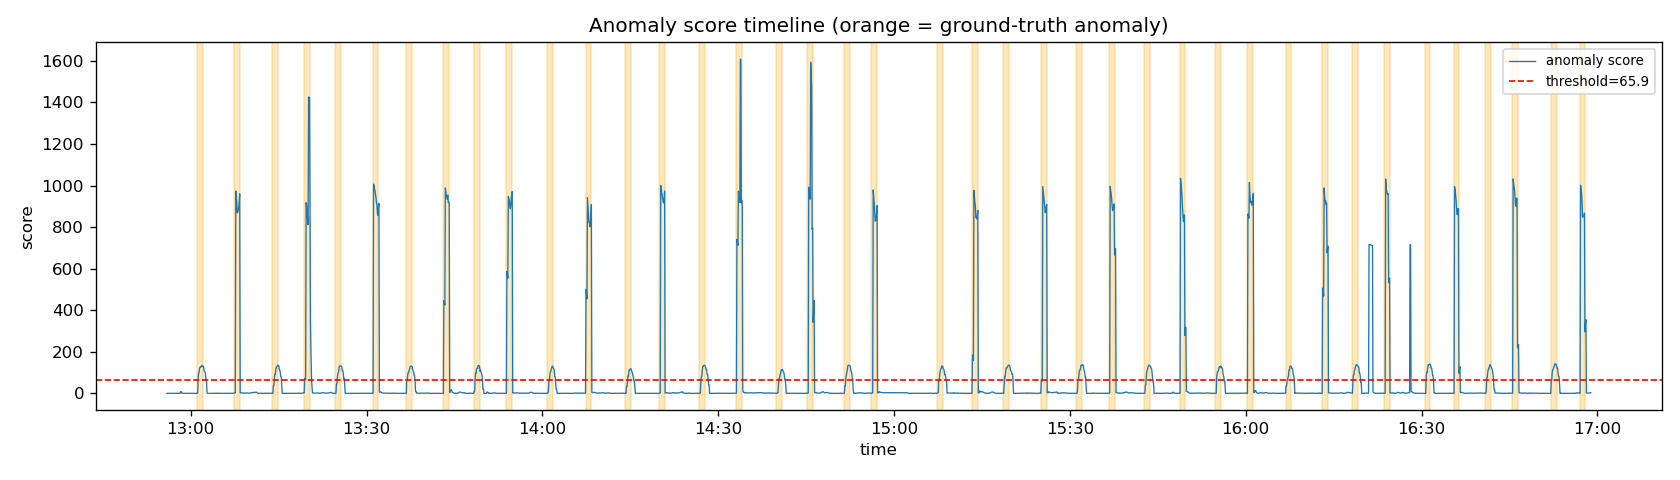

roc_pr_curves.png


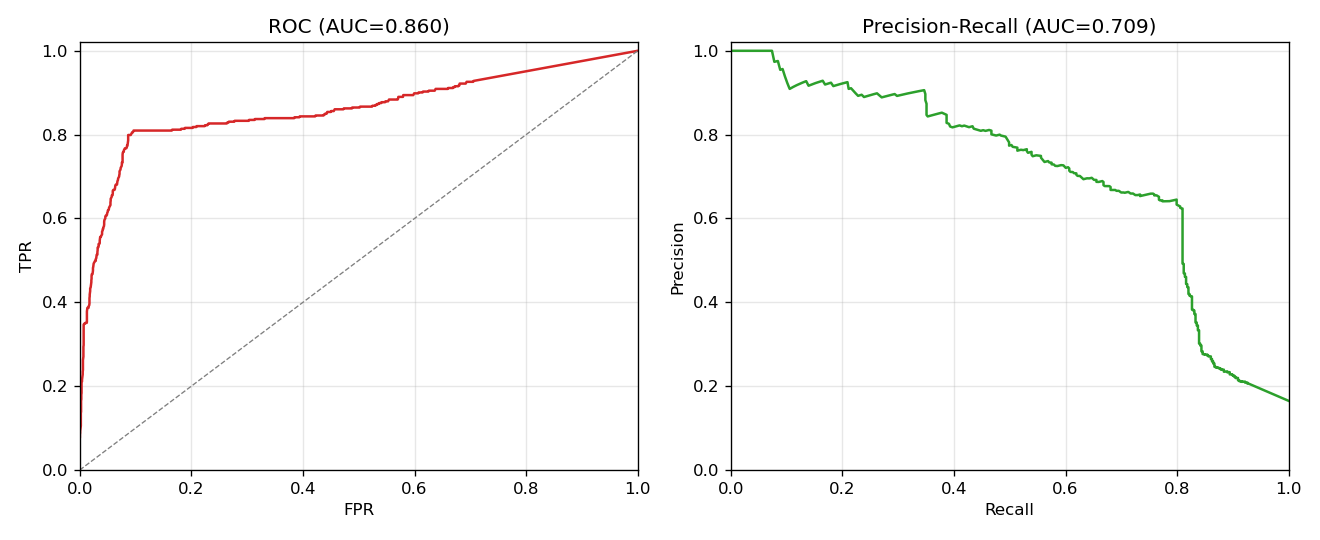

score_distribution.png


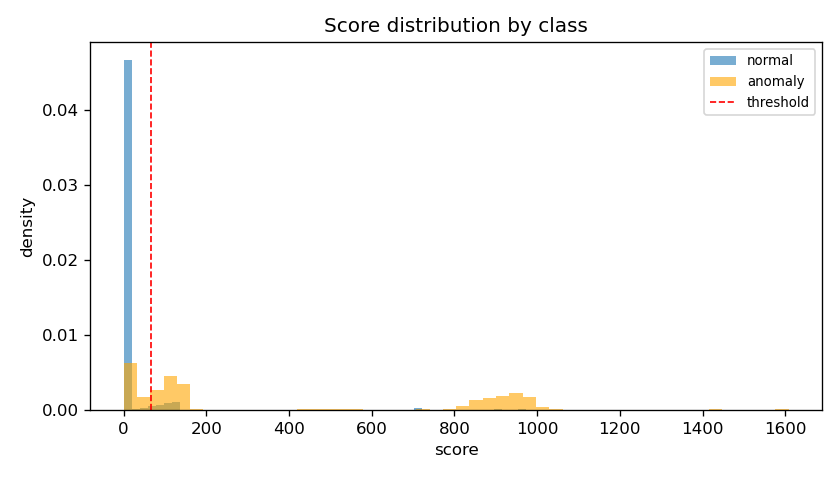

incident_delay_bar.png


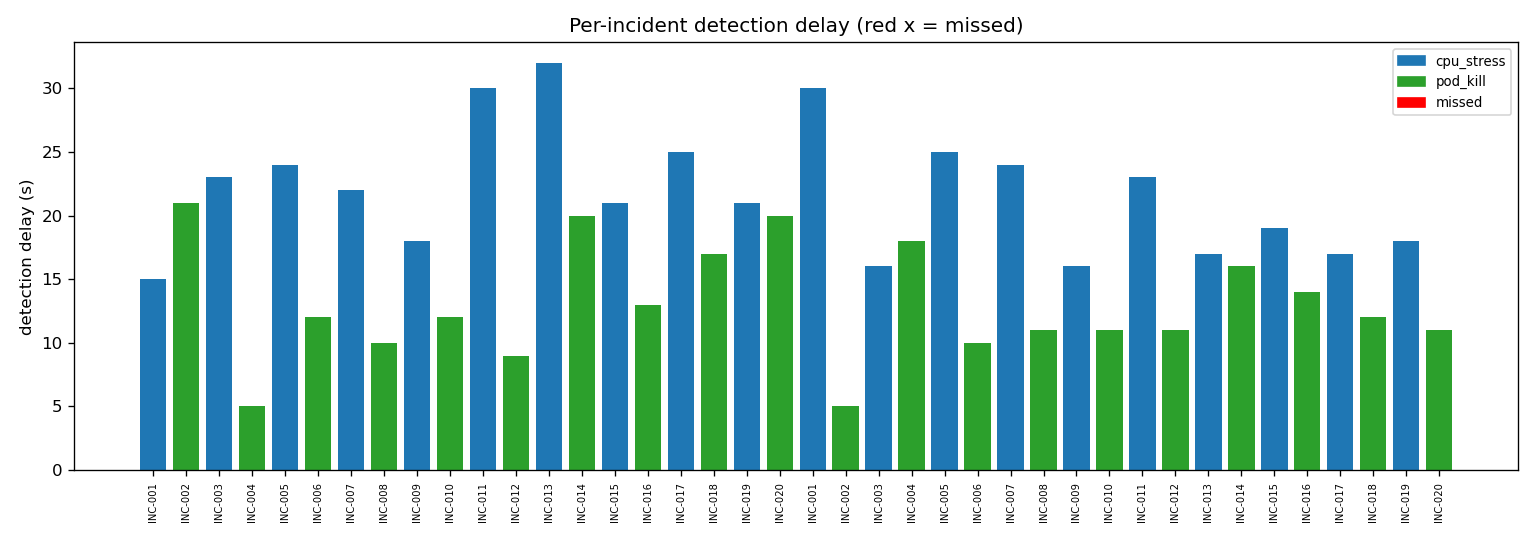

event_recall_by_fault_type.png


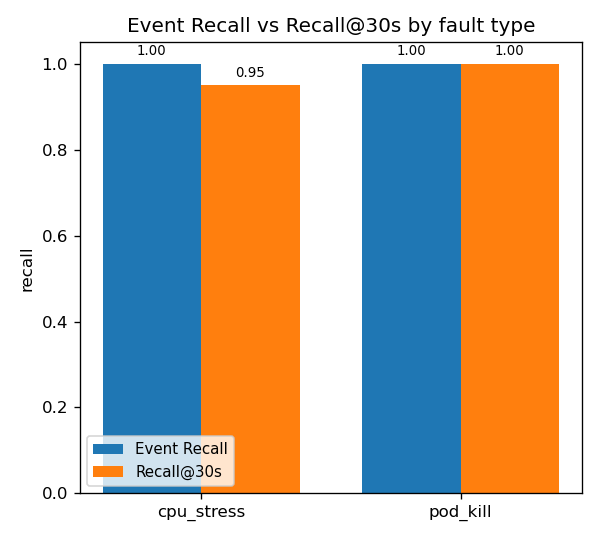

false_positive_timeline.png


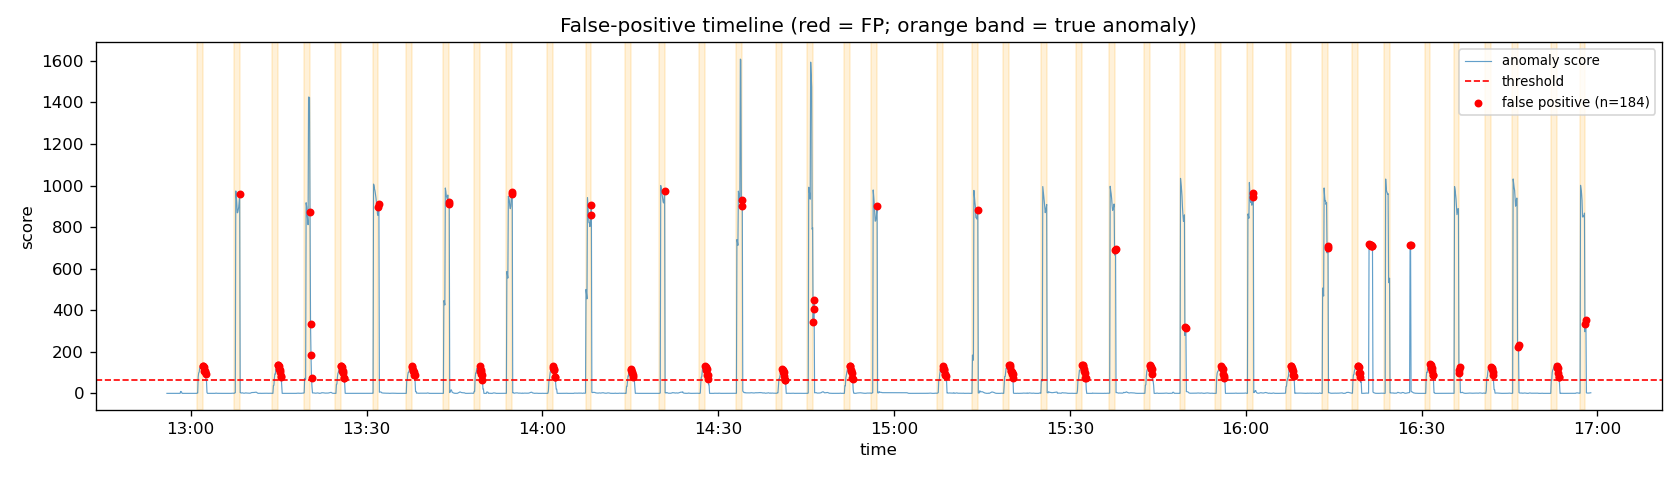

threshold_comparison.png


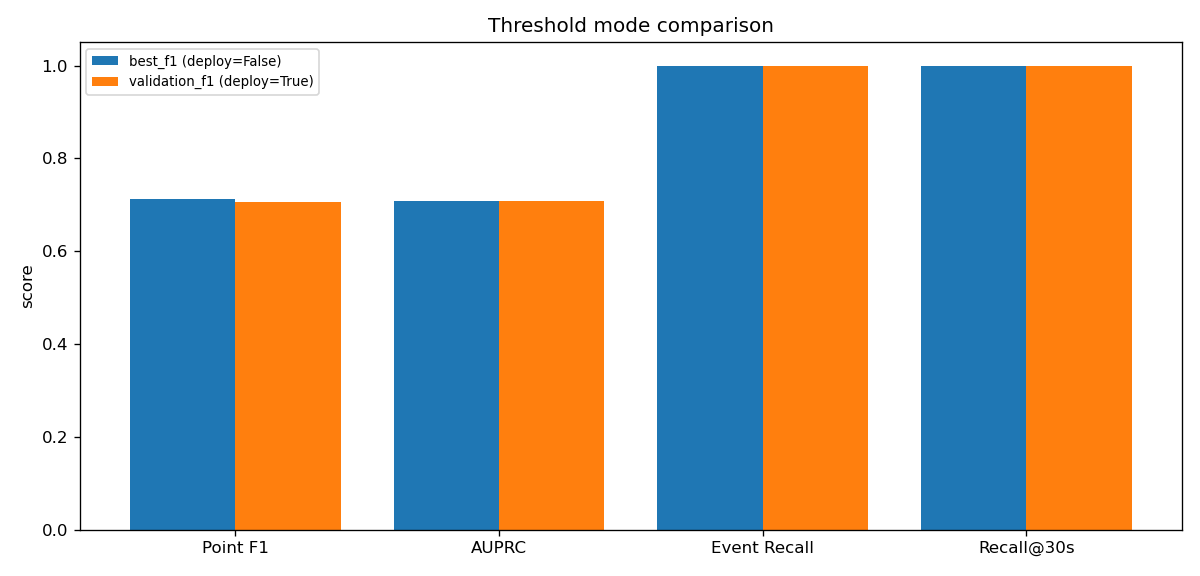

In [11]:
# 展示生成的图表
from IPython.display import Image, display
charts = [
    "score_timeline.png",             # 分数时间线 + 真实异常带
    "roc_pr_curves.png",              # ROC / PR 曲线
    "score_distribution.png",         # 正常 vs 异常分数分布
    "incident_delay_bar.png",         # 5.1 逐 incident 检测延迟（漏检红叉）
    "event_recall_by_fault_type.png", # 5.2 按故障类型的 Event Recall / Recall@30s
    "false_positive_timeline.png",    # 5.3 误报时间线
    "threshold_comparison.png",       # 5.4 best_f1 vs validation_f1 对比
]
for name in charts:
    p = result.output_dir / name
    if p.exists():
        print(name)
        display(Image(str(p)))

In [12]:
# 阈值模式对比表（best_f1 上界 vs validation_f1 可部署）
cmp_path = result.output_dir / "threshold_comparison.csv"
if cmp_path.exists():
    display(pd.read_csv(cmp_path))

,threshold_mode,threshold,threshold_deployable,point_f1,pr_auc,event_recall,recall_at_30s,false_alarms_per_hour,median_delay_seconds,missed_incidents
0,best_f1,33.256989,False,0.712665,0.708846,1.0,1.0,62.556391,13.0,0
1,validation_f1,15.480546,True,0.706542,0.708846,1.0,1.0,65.864662,13.0,0


In [13]:
# 逐 incident 检出 + 延迟明细
per_inc = pd.read_csv(result.output_dir / "per_incident.csv")
print(f"检出 {per_inc.detected.sum()}/{len(per_inc)} 个 incident")
display(per_inc.head(12))

检出 40/40 个 incident


,incident_id,fault_type,target_service,effect_start,effect_end,detected,first_alarm_time,delay_seconds,detected_within_15s,detected_within_30s,detected_within_60s
0,online_boutique_rca_6/INC-001,cpu_stress,recommendationservice,2026-05-30T13:01:02Z,2026-05-30T13:02:00Z,True,2026-05-30T13:01:17Z,15.0,True,True,True
1,online_boutique_rca_6/INC-002,pod_kill,cartservice,2026-05-30T13:07:21Z,2026-05-30T13:08:19Z,True,2026-05-30T13:07:42Z,21.0,False,True,True
2,online_boutique_rca_6/INC-003,cpu_stress,recommendationservice,2026-05-30T13:13:54Z,2026-05-30T13:14:52Z,True,2026-05-30T13:14:17Z,23.0,False,True,True
3,online_boutique_rca_6/INC-004,pod_kill,cartservice,2026-05-30T13:19:22Z,2026-05-30T13:20:21Z,True,2026-05-30T13:19:27Z,5.0,True,True,True
4,online_boutique_rca_6/INC-005,cpu_stress,recommendationservice,2026-05-30T13:24:38Z,2026-05-30T13:25:36Z,True,2026-05-30T13:25:02Z,24.0,False,True,True
5,online_boutique_rca_6/INC-006,pod_kill,cartservice,2026-05-30T13:31:00Z,2026-05-30T13:31:58Z,True,2026-05-30T13:31:12Z,12.0,True,True,True
6,online_boutique_rca_6/INC-007,cpu_stress,recommendationservice,2026-05-30T13:36:40Z,2026-05-30T13:37:38Z,True,2026-05-30T13:37:02Z,22.0,False,True,True
7,online_boutique_rca_6/INC-008,pod_kill,cartservice,2026-05-30T13:43:02Z,2026-05-30T13:44:00Z,True,2026-05-30T13:43:12Z,10.0,True,True,True
8,online_boutique_rca_6/INC-009,cpu_stress,recommendationservice,2026-05-30T13:48:14Z,2026-05-30T13:49:13Z,True,2026-05-30T13:48:32Z,18.0,False,True,True
9,online_boutique_rca_6/INC-010,pod_kill,cartservice,2026-05-30T13:53:45Z,2026-05-30T13:54:43Z,True,2026-05-30T13:53:57Z,12.0,True,True,True


## 6. 反复实验

每次 `pipe.run()` 都会创建一个新的时间戳目录，不会覆盖历史结果。你可以换不同算法/参数/阈值模式多次运行，然后对比 `output/` 下的各次结果。

### 离线提交方式

如果你在别处跑出了预测分数，也可以直接提交一个 `submission` DataFrame（参考 `examples/sample_submission.csv`），跳过 fit/predict：

```python
sub = pd.read_csv(DATASET / "examples" / "sample_submission.csv")
sub["anomaly_score"] = my_scores   # 填入你的分数
result = pipe.run(detector=None, submission=sub)
```

In [14]:
# 列出 output/ 下所有历史运行
out_root = PROJECT_ROOT / "output"
rows = []
if out_root.exists():
    for d in sorted(out_root.iterdir()):
        mj = d / "metrics.json"
        if d.is_dir() and mj.exists():
            mm = json.loads(mj.read_text(encoding="utf-8"))
            rows.append({
                "run": d.name,
                "point_f1": mm["point_level"]["point_f1"],
                "pr_auc": mm["ranking"]["pr_auc"],
                "event_recall": mm["event_level"]["event_recall"],
                "recall@30s": mm["event_level"]["recall_at_30s"],
                "far/h": mm["false_alarm"]["false_alarms_per_hour"],
                "median_delay": mm["event_level"]["median_detection_delay_seconds"],
                "thr_mode": mm["threshold"]["threshold_mode"],
                "deployable": mm["threshold"]["threshold_deployable"],
            })
pd.DataFrame(rows)

,run,point_f1,pr_auc,event_recall,recall@30s,far/h,median_delay,thr_mode,deployable
0,20260601_035535_my_detector,0.564551,0.632368,0.975,0.575,55.037594,15.0,best_f1,False
1,20260608_075439_usad_v3_fpr010_topk10_win6,0.486590,0.577146,0.875,0.575,95.338346,18.0,fixed_fpr,True
2,20260608_075614_usad_v3_fpr007_topk10_win6,0.446352,0.577146,0.600,0.525,75.488722,12.0,fixed_fpr,True
3,20260608_080430_usad_dual_window_fusion_fpr007,0.691235,0.708846,1.000,0.975,55.338346,17.0,fixed_fpr,True
